<a href="https://colab.research.google.com/github/PromitMukherjee/Machine_learning_Algorithm/blob/main/Supervised_Learning/Tradional_Descision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ID3 DECISION TREE — FROM SCRATCH
Total samples    : 10,000
Training samples : 8,001
Testing samples  : 1,999
Number features  : 2
Number classes   : 2
Tree depth       : 10
Number of leaves : 176

----------------------------------------------------------------------
TRAINING PERFORMANCE
----------------------------------------------------------------------
Accuracy  : 0.9459
Precision : 0.9462
Recall    : 0.9459
F1 Score  : 0.9459

----------------------------------------------------------------------
TEST PERFORMANCE
----------------------------------------------------------------------
Accuracy  : 0.9250
Precision : 0.9250
Recall    : 0.9250
F1 Score  : 0.9250

----------------------------------------------------------------------
PER-CLASS TEST METRICS
----------------------------------------------------------------------
Class 0: Precision = 0.9302, Recall = 0.9191, F1 = 0.9246
Class 1: Precision = 0.9198, Recall = 0.9309, F1 = 0.9253

---------------------------------------------

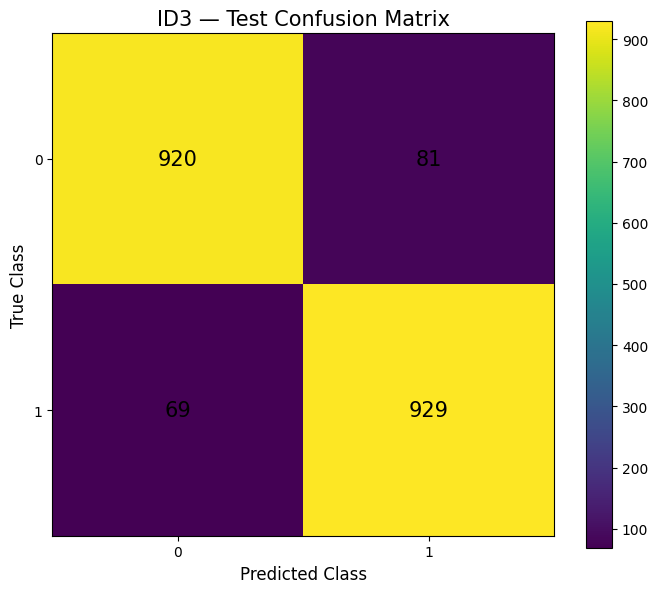

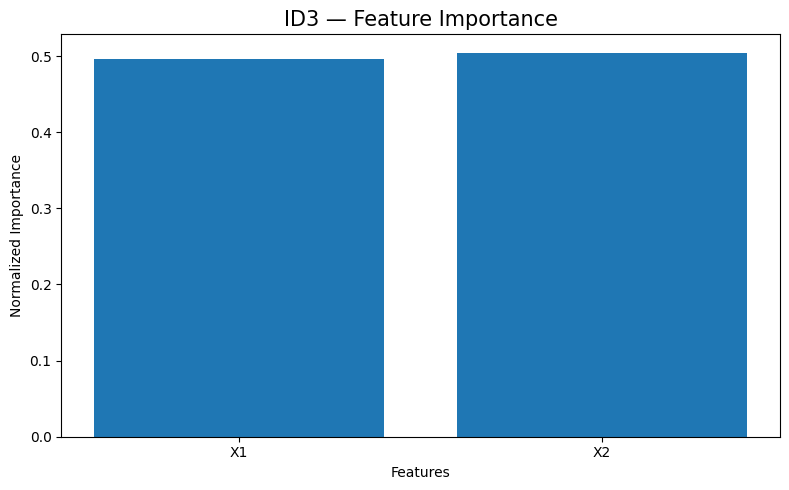

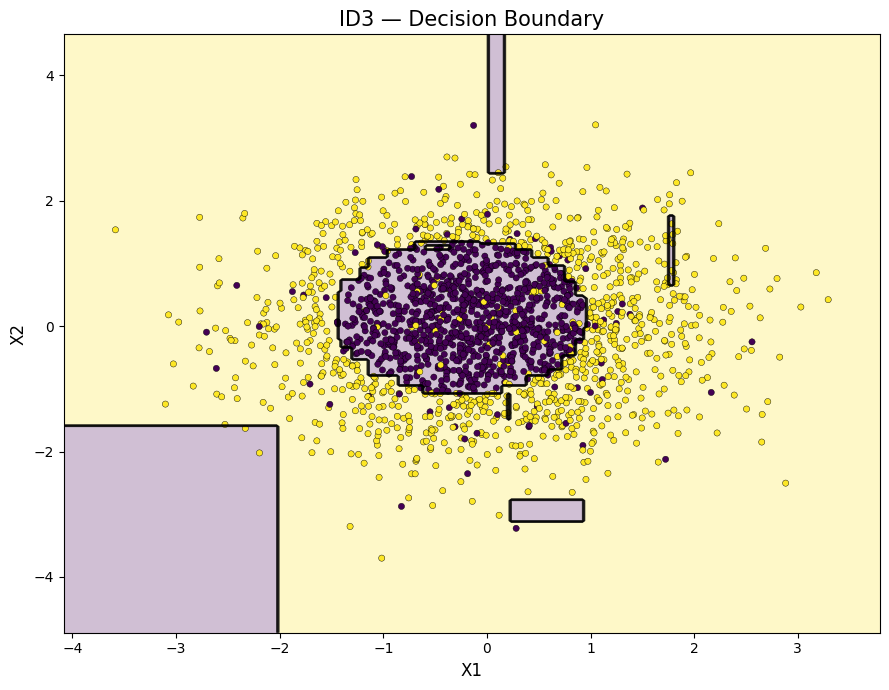

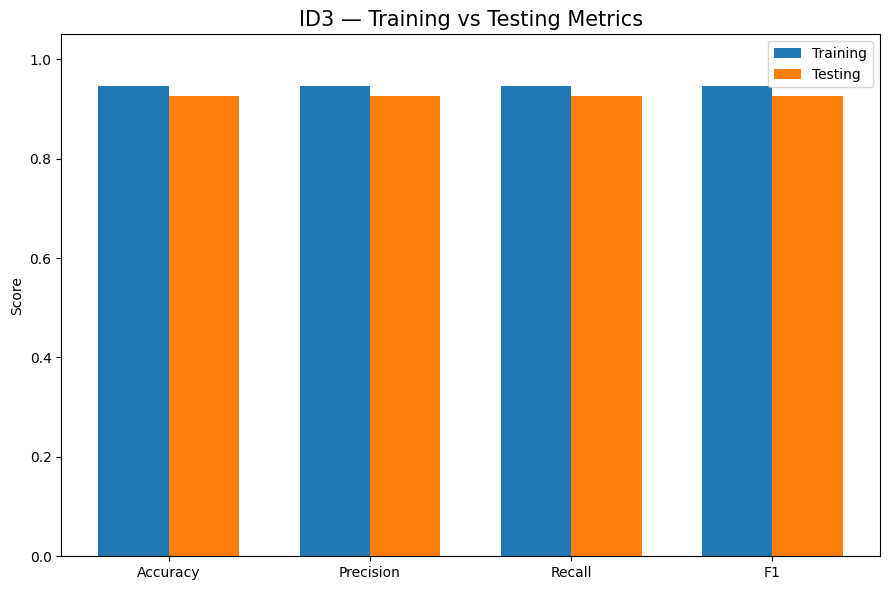

In [2]:
# ============================================================
# ID3 DECISION TREE FROM SCRATCH
# ============================================================
# Libraries:
#   NumPy
#   Matplotlib
#
# NO sklearn is used for:
#   - Decision Tree
#   - Train/Test Split
#   - Confusion Matrix
#   - Evaluation Metrics
#
# Includes:
#   1. Entropy
#   2. Information Gain
#   3. Numerical feature splitting
#   4. Recursive tree construction
#   5. Stopping criteria
#   6. Prediction
#   7. Accuracy
#   8. Precision
#   9. Recall
#  10. F1 Score
#  11. Confusion Matrix
#  12. Feature Importance
#  13. Decision Boundary
#
# Dataset:
#   10,000 samples
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. TREE NODE
# ============================================================

class TreeNode:

    def __init__(
        self,
        feature_index=None,
        feature_name=None,
        threshold=None,
        is_leaf=False,
        prediction=None,
        class_counts=None,
        depth=0
    ):

        self.feature_index = feature_index
        self.feature_name = feature_name
        self.threshold = threshold

        self.is_leaf = is_leaf
        self.prediction = prediction

        self.class_counts = class_counts

        self.depth = depth

        self.left = None
        self.right = None


# ============================================================
# 2. ID3 CLASSIFIER
# ============================================================

class ID3Classifier:

    def __init__(
        self,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        min_gain=1e-10
    ):

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.min_gain = min_gain

        self.root = None

        self.classes_ = None
        self.n_classes_ = None
        self.n_features_ = None

        self.feature_names_ = None
        self.feature_importances_ = None

        self.tree_depth_ = 0
        self.n_leaves_ = 0


    # ========================================================
    # ENTROPY
    # ========================================================

    def _entropy(self, y):

        if len(y) == 0:
            return 0.0

        _, counts = np.unique(
            y,
            return_counts=True
        )

        probabilities = counts / len(y)

        entropy = 0.0

        for p in probabilities:

            if p > 0:

                entropy -= (
                    p * np.log2(p)
                )

        return entropy


    # ========================================================
    # INFORMATION GAIN
    # ========================================================

    def _information_gain(
        self,
        y,
        left_y,
        right_y
    ):

        parent_entropy = self._entropy(y)

        n = len(y)

        if (
            len(left_y) == 0
            or
            len(right_y) == 0
        ):

            return 0.0

        left_weight = (
            len(left_y) / n
        )

        right_weight = (
            len(right_y) / n
        )

        child_entropy = (
            left_weight
            *
            self._entropy(left_y)
            +
            right_weight
            *
            self._entropy(right_y)
        )

        gain = (
            parent_entropy
            -
            child_entropy
        )

        return gain


    # ========================================================
    # BEST NUMERICAL SPLIT
    # ========================================================

    def _best_numeric_split(
        self,
        X_column,
        y
    ):

        unique_values = np.unique(
            X_column
        )

        if len(unique_values) <= 1:

            return None, -np.inf

        thresholds = (
            unique_values[:-1]
            +
            unique_values[1:]
        ) / 2.0

        best_threshold = None

        best_gain = -np.inf

        for threshold in thresholds:

            left_mask = (
                X_column <= threshold
            )

            right_mask = (
                X_column > threshold
            )

            left_count = np.sum(
                left_mask
            )

            right_count = np.sum(
                right_mask
            )

            if (
                left_count
                <
                self.min_samples_leaf
                or
                right_count
                <
                self.min_samples_leaf
            ):

                continue

            left_y = y[left_mask]

            right_y = y[right_mask]

            gain = self._information_gain(
                y,
                left_y,
                right_y
            )

            if gain > best_gain:

                best_gain = gain

                best_threshold = threshold

        return (
            best_threshold,
            best_gain
        )


    # ========================================================
    # FIND BEST SPLIT
    # ========================================================

    def _best_split(
        self,
        X,
        y
    ):

        best_feature = None

        best_threshold = None

        best_gain = -np.inf

        for feature_index in range(
            self.n_features_
        ):

            column = X[
                :,
                feature_index
            ]

            threshold, gain = (
                self._best_numeric_split(
                    column,
                    y
                )
            )

            if gain > best_gain:

                best_gain = gain

                best_feature = (
                    feature_index
                )

                best_threshold = (
                    threshold
                )

        return (
            best_feature,
            best_threshold,
            best_gain
        )


    # ========================================================
    # MAJORITY CLASS
    # ========================================================

    def _majority_class(self, y):

        values, counts = np.unique(
            y,
            return_counts=True
        )

        return values[
            np.argmax(counts)
        ]


    # ========================================================
    # BUILD TREE
    # ========================================================

    def _build_tree(
        self,
        X,
        y,
        depth=0
    ):

        majority_class = (
            self._majority_class(y)
        )

        class_counts = {}

        for c in self.classes_:

            class_counts[c] = np.sum(
                y == c
            )

        node = TreeNode(
            is_leaf=False,
            prediction=majority_class,
            class_counts=class_counts,
            depth=depth
        )

        self.tree_depth_ = max(
            self.tree_depth_,
            depth
        )


        # ----------------------------------------------------
        # STOPPING CONDITION 1
        # Pure node
        # ----------------------------------------------------

        if len(np.unique(y)) == 1:

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ----------------------------------------------------
        # STOPPING CONDITION 2
        # Maximum depth
        # ----------------------------------------------------

        if (
            self.max_depth is not None
            and
            depth >= self.max_depth
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ----------------------------------------------------
        # STOPPING CONDITION 3
        # Minimum samples
        # ----------------------------------------------------

        if (
            len(y)
            <
            self.min_samples_split
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ----------------------------------------------------
        # FIND BEST SPLIT
        # ----------------------------------------------------

        (
            feature_index,
            threshold,
            gain
        ) = self._best_split(
            X,
            y
        )


        # ----------------------------------------------------
        # STOPPING CONDITION 4
        # No useful split
        # ----------------------------------------------------

        if (
            feature_index is None
            or
            threshold is None
            or
            gain <= self.min_gain
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ----------------------------------------------------
        # STORE SPLIT
        # ----------------------------------------------------

        node.feature_index = (
            feature_index
        )

        node.feature_name = (
            self.feature_names_[
                feature_index
            ]
        )

        node.threshold = threshold


        # ----------------------------------------------------
        # FEATURE IMPORTANCE
        # ----------------------------------------------------

        self.feature_importances_[
            feature_index
        ] += (
            gain * len(y)
        )


        # ----------------------------------------------------
        # SPLIT DATA
        # ----------------------------------------------------

        left_mask = (
            X[:, feature_index]
            <=
            threshold
        )

        right_mask = (
            X[:, feature_index]
            >
            threshold
        )


        X_left = X[left_mask]

        y_left = y[left_mask]


        X_right = X[right_mask]

        y_right = y[right_mask]


        # ----------------------------------------------------
        # MINIMUM LEAF CHECK
        # ----------------------------------------------------

        if (
            len(y_left)
            <
            self.min_samples_leaf
            or
            len(y_right)
            <
            self.min_samples_leaf
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ----------------------------------------------------
        # RECURSIVE TREE BUILDING
        # ----------------------------------------------------

        node.left = self._build_tree(
            X_left,
            y_left,
            depth + 1
        )

        node.right = self._build_tree(
            X_right,
            y_right,
            depth + 1
        )

        return node


    # ========================================================
    # FIT
    # ========================================================

    def fit(
        self,
        X,
        y,
        feature_names=None
    ):

        X = np.asarray(X)

        y = np.asarray(y)

        if X.ndim != 2:

            raise ValueError(
                "X must be 2-dimensional."
            )

        if y.ndim != 1:

            raise ValueError(
                "y must be 1-dimensional."
            )

        if len(X) != len(y):

            raise ValueError(
                "X and y must contain "
                "the same number of samples."
            )

        self.n_features_ = (
            X.shape[1]
        )

        self.classes_ = np.unique(
            y
        )

        self.n_classes_ = (
            len(self.classes_)
        )


        if feature_names is None:

            self.feature_names_ = [
                f"Feature_{i}"
                for i in range(
                    self.n_features_
                )
            ]

        else:

            self.feature_names_ = list(
                feature_names
            )


        self.feature_importances_ = (
            np.zeros(
                self.n_features_
            )
        )

        self.tree_depth_ = 0

        self.n_leaves_ = 0


        self.root = self._build_tree(
            X,
            y
        )


        # Normalize feature importance

        total = np.sum(
            self.feature_importances_
        )

        if total > 0:

            self.feature_importances_ /= (
                total
            )

        return self


    # ========================================================
    # PREDICT SINGLE SAMPLE
    # ========================================================

    def _predict_sample(
        self,
        x,
        node
    ):

        if node.is_leaf:

            return node.prediction


        feature_value = x[
            node.feature_index
        ]


        if (
            feature_value
            <=
            node.threshold
        ):

            return self._predict_sample(
                x,
                node.left
            )

        else:

            return self._predict_sample(
                x,
                node.right
            )


    # ========================================================
    # PREDICT
    # ========================================================

    def predict(self, X):

        X = np.asarray(X)

        predictions = []

        for x in X:

            predictions.append(
                self._predict_sample(
                    x,
                    self.root
                )
            )

        return np.asarray(
            predictions
        )


    # ========================================================
    # SCORE
    # ========================================================

    def score(
        self,
        X,
        y
    ):

        predictions = self.predict(
            X
        )

        return np.mean(
            predictions == y
        )


# ============================================================
# 3. TRAIN / TEST SPLIT FROM SCRATCH
# ============================================================

def train_test_split_manual(
    X,
    y,
    test_size=0.20,
    random_state=42
):

    rng = np.random.default_rng(
        random_state
    )

    train_indices = []

    test_indices = []


    # Stratified split

    for cls in np.unique(y):

        indices = np.where(
            y == cls
        )[0]

        rng.shuffle(
            indices
        )

        n_test = int(
            len(indices)
            *
            test_size
        )

        test_indices.extend(
            indices[:n_test]
        )

        train_indices.extend(
            indices[n_test:]
        )


    train_indices = np.asarray(
        train_indices
    )

    test_indices = np.asarray(
        test_indices
    )


    rng.shuffle(
        train_indices
    )

    rng.shuffle(
        test_indices
    )


    return (
        X[train_indices],
        X[test_indices],
        y[train_indices],
        y[test_indices]
    )


# ============================================================
# 4. CONFUSION MATRIX FROM SCRATCH
# ============================================================

def confusion_matrix_manual(
    y_true,
    y_pred
):

    labels = np.unique(
        np.concatenate(
            [
                y_true,
                y_pred
            ]
        )
    )

    matrix = np.zeros(
        (
            len(labels),
            len(labels)
        ),
        dtype=int
    )


    label_to_index = {
        label: i
        for i, label in enumerate(
            labels
        )
    }


    for true, pred in zip(
        y_true,
        y_pred
    ):

        matrix[
            label_to_index[true],
            label_to_index[pred]
        ] += 1


    return matrix, labels


# ============================================================
# 5. CLASSIFICATION METRICS FROM SCRATCH
# ============================================================

def classification_metrics(
    y_true,
    y_pred
):

    cm, labels = (
        confusion_matrix_manual(
            y_true,
            y_pred
        )
    )


    accuracy = (
        np.trace(cm)
        /
        np.sum(cm)
    )


    precisions = []

    recalls = []

    f1_scores = []


    for i in range(
        len(labels)
    ):

        TP = cm[i, i]

        FP = (
            np.sum(cm[:, i])
            -
            TP
        )

        FN = (
            np.sum(cm[i, :])
            -
            TP
        )


        precision = (
            TP / (TP + FP)
            if (TP + FP) > 0
            else 0.0
        )


        recall = (
            TP / (TP + FN)
            if (TP + FN) > 0
            else 0.0
        )


        if (
            precision + recall
            >
            0
        ):

            f1 = (
                2
                *
                precision
                *
                recall
                /
                (
                    precision
                    +
                    recall
                )
            )

        else:

            f1 = 0.0


        precisions.append(
            precision
        )

        recalls.append(
            recall
        )

        f1_scores.append(
            f1
        )


    macro_precision = np.mean(
        precisions
    )

    macro_recall = np.mean(
        recalls
    )

    macro_f1 = np.mean(
        f1_scores
    )


    return {
        "accuracy": accuracy,
        "precision": macro_precision,
        "recall": macro_recall,
        "f1": macro_f1,
        "labels": labels,
        "confusion_matrix": cm,
        "per_class_precision": precisions,
        "per_class_recall": recalls,
        "per_class_f1": f1_scores
    }


# ============================================================
# 6. CREATE LARGE DATASET
# ============================================================

rng = np.random.default_rng(
    42
)

n_samples = 10_000


# ------------------------------------------------------------
# Generate 2D features
# ------------------------------------------------------------

X = rng.normal(
    0,
    1,
    size=(
        n_samples,
        2
    )
)


x1 = X[:, 0]

x2 = X[:, 1]


# ------------------------------------------------------------
# Nonlinear target function
# ------------------------------------------------------------

decision_function = (
    x1**2
    +
    x2**2
    +
    0.5 * x1
    -
    0.3 * x2
)


y = (
    decision_function > 1.4
).astype(int)


# ------------------------------------------------------------
# Add 5% label noise
# ------------------------------------------------------------

noise = (
    rng.random(
        n_samples
    )
    <
    0.05
)


y[noise] = (
    1 - y[noise]
)


feature_names = [
    "X1",
    "X2"
]


# ============================================================
# 7. TRAIN / TEST SPLIT
# ============================================================

(
    X_train,
    X_test,
    y_train,
    y_test
) = train_test_split_manual(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 8. CREATE AND TRAIN MODEL
# ============================================================

model = ID3Classifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    min_gain=1e-6
)


model.fit(
    X_train,
    y_train,
    feature_names=feature_names
)


# ============================================================
# 9. PREDICTIONS
# ============================================================

y_train_pred = model.predict(
    X_train
)

y_test_pred = model.predict(
    X_test
)


# ============================================================
# 10. EVALUATION
# ============================================================

train_metrics = (
    classification_metrics(
        y_train,
        y_train_pred
    )
)


test_metrics = (
    classification_metrics(
        y_test,
        y_test_pred
    )
)


# ============================================================
# 11. PRINT RESULTS
# ============================================================

print("=" * 70)

print(
    "ID3 DECISION TREE — FROM SCRATCH"
)

print("=" * 70)

print(
    f"Total samples    : {n_samples:,}"
)

print(
    f"Training samples : {len(X_train):,}"
)

print(
    f"Testing samples  : {len(X_test):,}"
)

print(
    f"Number features  : {model.n_features_}"
)

print(
    f"Number classes   : {model.n_classes_}"
)

print(
    f"Tree depth       : {model.tree_depth_}"
)

print(
    f"Number of leaves : {model.n_leaves_}"
)


# ============================================================
# TRAINING METRICS
# ============================================================

print()
print("-" * 70)

print(
    "TRAINING PERFORMANCE"
)

print("-" * 70)

print(
    f"Accuracy  : "
    f"{train_metrics['accuracy']:.4f}"
)

print(
    f"Precision : "
    f"{train_metrics['precision']:.4f}"
)

print(
    f"Recall    : "
    f"{train_metrics['recall']:.4f}"
)

print(
    f"F1 Score  : "
    f"{train_metrics['f1']:.4f}"
)


# ============================================================
# TEST METRICS
# ============================================================

print()
print("-" * 70)

print(
    "TEST PERFORMANCE"
)

print("-" * 70)

print(
    f"Accuracy  : "
    f"{test_metrics['accuracy']:.4f}"
)

print(
    f"Precision : "
    f"{test_metrics['precision']:.4f}"
)

print(
    f"Recall    : "
    f"{test_metrics['recall']:.4f}"
)

print(
    f"F1 Score  : "
    f"{test_metrics['f1']:.4f}"
)


# ============================================================
# 12. PER-CLASS METRICS
# ============================================================

print()
print("-" * 70)

print(
    "PER-CLASS TEST METRICS"
)

print("-" * 70)


for i, label in enumerate(
    test_metrics["labels"]
):

    print(
        f"Class {label}: "
        f"Precision = "
        f"{test_metrics['per_class_precision'][i]:.4f}, "
        f"Recall = "
        f"{test_metrics['per_class_recall'][i]:.4f}, "
        f"F1 = "
        f"{test_metrics['per_class_f1'][i]:.4f}"
    )


# ============================================================
# 13. CONFUSION MATRIX
# ============================================================

cm = test_metrics[
    "confusion_matrix"
]

labels = test_metrics[
    "labels"
]


print()
print("-" * 70)

print(
    "TEST CONFUSION MATRIX"
)

print("-" * 70)

print(cm)


# ============================================================
# 14. CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "ID3 — Test Confusion Matrix",
    fontsize=15
)

plt.xlabel(
    "Predicted Class",
    fontsize=12
)

plt.ylabel(
    "True Class",
    fontsize=12
)

plt.xticks(
    range(len(labels)),
    labels
)

plt.yticks(
    range(len(labels)),
    labels
)


for i in range(
    len(labels)
):

    for j in range(
        len(labels)
    ):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=15
        )


plt.colorbar()

plt.tight_layout()

plt.show()


# ============================================================
# 15. FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    model.feature_names_,
    model.feature_importances_
)

plt.title(
    "ID3 — Feature Importance",
    fontsize=15
)

plt.xlabel(
    "Features"
)

plt.ylabel(
    "Normalized Importance"
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. DECISION BOUNDARY VISUALIZATION (FIXED)
# ============================================================

x_min = (
    X[:, 0].min()
    -
    0.5
)

x_max = (
    X[:, 0].max()
    +
    0.5
)

y_min = (
    X[:, 1].min()
    -
    0.5
)

y_max = (
    X[:, 1].max()
    +
    0.5
)


resolution = 300


xx, yy = np.meshgrid(
    np.linspace(
        x_min,
        x_max,
        resolution
    ),
    np.linspace(
        y_min,
        y_max,
        resolution
    )
)


grid = np.column_stack(
    [
        xx.ravel(),
        yy.ravel()
    ]
)


grid_predictions = model.predict(
    grid
)


grid_predictions = (
    grid_predictions.reshape(
        xx.shape
    )
)


plt.figure(
    figsize=(9, 7)
)


# Fixed: Using contour instead of contourf to prevent background bleeding
plt.contour(
    xx,
    yy,
    grid_predictions,
    colors="black",
    linewidths=0.8,
    alpha=0.6
)

# Fixed: Using pcolormesh with explicit limits matching the data range to avoid outlier boundary artifacts
plt.pcolormesh(
    xx,
    yy,
    grid_predictions,
    cmap="viridis",
    alpha=0.25,
    shading="auto"
)


# Plot test observations

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    cmap="viridis",
    s=20,
    edgecolors="black",
    linewidths=0.3
)


plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.title(
    "ID3 — Decision Boundary",
    fontsize=15
)

plt.xlabel(
    "X1",
    fontsize=12
)

plt.ylabel(
    "X2",
    fontsize=12
)

plt.tight_layout()

plt.show()


# ============================================================
# 17. METRICS COMPARISON VISUALIZATION
# ============================================================

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

train_values = [
    train_metrics["accuracy"],
    train_metrics["precision"],
    train_metrics["recall"],
    train_metrics["f1"]
]

test_values = [
    test_metrics["accuracy"],
    test_metrics["precision"],
    test_metrics["recall"],
    test_metrics["f1"]
]


x = np.arange(
    len(metric_names)
)

width = 0.35


plt.figure(
    figsize=(9, 6)
)


plt.bar(
    x - width / 2,
    train_values,
    width,
    label="Training"
)


plt.bar(
    x + width / 2,
    test_values,
    width,
    label="Testing"
)


plt.xticks(
    x,
    metric_names
)

plt.ylim(
    0,
    1.05
)

plt.ylabel(
    "Score"
)

plt.title(
    "ID3 — Training vs Testing Metrics",
    fontsize=15
)

plt.legend()

plt.tight_layout()

plt.show()